In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
military_power = pd.read_excel('World military power.xlsx')
military_power

,Military Strength,Military Strength Power Index,Aircraft Strength,Aircraft Strength value,Fighter/Interceptor Strength,Fighter/Interceptor Strength value,Attack Aircraft Strength,Attack Aircraft Strength value,Transport Aircraft Fleet Strength,Transport Aircraft Fleet Strength value,...,Total Population,Total Population value,Total Square Land Area,Total Square Land Area value,Total Coastline Coverage,Total Coastline Coverage value,Total Waterway Coverage,Total Waterway Coverage value,Total Border Coverage,Total Border Coverage value
0,Afghanistan,1.3444,Afghanistan,260,Afghanistan,0,Afghanistan,25,Afghanistan,30,...,Afghanistan,"3,49,40,837",Afghanistan,"6,52,230",Afghanistan,0,Afghanistan,1200,Afghanistan,5987.0
1,Albania,2.3137,Albania,19,Albania,0,Albania,0,Albania,0,...,Albania,"30,57,220",Albania,28748,Albania,362,Albania,41,Albania,691.0
2,Algeria,0.4659,Algeria,551,Algeria,103,Algeria,22,Algeria,59,...,Algeria,"4,16,57,488",Algeria,"23,81,741",Algeria,998,Algeria,0,Algeria,6734.0
3,Angola,0.8379,Angola,295,Angola,72,Angola,18,Angola,30,...,Angola,"3,03,55,880",Angola,"12,46,700",Angola,1600,Angola,1300,Angola,5369.0
4,Argentina,0.6521,Argentina,227,Argentina,24,Argentina,7,Argentina,9,...,Argentina,"4,46,94,198",Argentina,"27,80,400",Argentina,4989,Argentina,11000,Argentina,11968.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,Venezuela,0.6449,Venezuela,260,Venezuela,38,Venezuela,0,Venezuela,52,...,Venezuela,"3,16,89,176",Venezuela,"9,12,050",Venezuela,2800,Venezuela,7100,Venezuela,5267.0
134,Vietnam,0.3559,Vietnam,293,Vietnam,77,Vietnam,0,Vietnam,38,...,Vietnam,"9,70,40,334",Vietnam,"3,31,210",Vietnam,3444,Vietnam,17702,Vietnam,4616.0
135,Yemen,1.2412,Yemen,169,Yemen,77,Yemen,0,Yemen,8,...,Yemen,"2,86,67,230",Yemen,"5,27,968",Yemen,1906,Yemen,0,Yemen,1601.0
136,Zambia,1.6464,Zambia,108,Zambia,18,Zambia,0,Zambia,11,...,Zambia,"1,64,45,079",Zambia,"7,52,618",NaN,NaN,Zambia,2250,Zambia,6043.0


In [3]:
military_power.columns

Index(['Military Strength', 'Military Strength Power Index',
       'Aircraft Strength', 'Aircraft Strength value',
       'Fighter/Interceptor Strength', 'Fighter/Interceptor Strength value',
       'Attack Aircraft Strength', 'Attack Aircraft Strength value',
       'Transport Aircraft Fleet Strength',
       'Transport Aircraft Fleet Strength value', 'Trainer Aircraft Fleet',
       'Trainer Aircraft Fleet value', 'Helicopter Fleet Strength',
       'Helicopter Fleet Strength value', 'Attack Helicopter Fleet Strength',
       'Attack Helicopter Fleet Strength value', 'Tank Strength',
       'Tank Strength value', 'AFV/APC Strength', 'AFV/APC Strength value',
       'Self-Propelled Artillery Strength',
       'Self-Propelled Artillery Strength value', 'Towed Artillery Strength',
       'Towed Artillery Strength value', 'Rocket Projector Strength',
       'Rocket Projector Strength value', 'Navy Fleet Strengths',
       'Navy Fleet Strengths value', 'Aircraft Carrier Fleet Strength',


In [4]:
# Rename the first column to represent country
military_power.rename(columns={'Military Strength': 'Country'}, inplace=True)

# Word to search for in column names
target_word = 'value'

# Hard-code these columns to keep
specific_cols_to_keep = ['Country', 'Military Strength Power Index']

# Create a list of columns to keep
columns_to_keep = []
for col in military_power.columns:
    if target_word in col or col in specific_cols_to_keep:
        columns_to_keep.append(col)

# Filter the DataFrame
military_power = military_power[columns_to_keep]

# Word to remove
word_to_remove = 'value'

# Remove the word 'value' from all column names for visual appeal
military_power.columns = military_power.columns.str.replace(word_to_remove, '')


military_power.columns = (
    military_power.columns
    .str.replace(word_to_remove, '', regex=False)  # safer: no regex behavior
    .str.strip()                                  # remove leading/trailing whitespace
    .str.replace(r'\s+', ' ', regex=True)         # collapse multiple spaces into one
)

# Remove all commas from the entire DataFrame
military_power = military_power.applymap(lambda x: x.replace(',', '') if isinstance(x, str) else x)

# Convert columns to numeric
excluded_column = 'Country'
columns_to_convert = [col for col in military_power.columns if col != excluded_column]
for col in columns_to_convert:
    military_power[col] = pd.to_numeric(military_power[col], errors='coerce')

military_power

/var/folders/cf/4zrkk0lx1nbdx9tpklpk4jc00000gn/T/ipykernel_21076/579168762.py:34: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  military_power = military_power.applymap(lambda x: x.replace(',', '') if isinstance(x, str) else x)


,Country,Military Strength Power Index,Aircraft Strength,Fighter/Interceptor Strength,Attack Aircraft Strength,Transport Aircraft Fleet Strength,Trainer Aircraft Fleet,Helicopter Fleet Strength,Attack Helicopter Fleet Strength,Tank Strength,...,Airport Totals,Oil Production,Oil Consumption,Proven Oil Reserves,Available Manpower,Total Population,Total Square Land Area,Total Coastline Coverage,Total Waterway Coverage,Total Border Coverage
0,Afghanistan,1.3444,260,0,25,30,0,187,0,0,...,43,0,5500,0,14325743,34940837,652230,0.0,1200,5987.0
1,Albania,2.3137,19,0,0,0,0,19,0,0,...,4,16000,42500,168300000,1519438,3057220,28748,362.0,41,691.0
2,Algeria,0.4659,551,103,22,59,87,257,45,880,...,157,1306000,325000,12200000000,20741263,41657488,2381741,998.0,0,6734.0
3,Angola,0.8379,295,72,18,30,47,126,15,379,...,176,1666000,82300,8273000000,6244205,30355880,1246700,1600.0,1300,5369.0
4,Argentina,0.6521,227,24,7,9,64,100,0,370,...,1138,479400,685000,2185000000,20179430,44694198,2780400,4989.0,11000,11968.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,Venezuela,0.6449,260,38,0,52,82,86,10,390,...,444,2007000,575000,300900000000,14260129,31689176,912050,2800.0,7100,5267.0
134,Vietnam,0.3559,293,77,0,38,36,138,25,2615,...,45,271400,525000,4400000000,51043216,97040334,331210,3444.0,17702,4616.0
135,Yemen,1.2412,169,77,0,8,21,61,14,620,...,57,12260,145000,3000000000,11266221,28667230,527968,1906.0,0,1601.0
136,Zambia,1.6464,108,18,0,11,52,27,0,75,...,88,0,21000,0,6166905,16445079,752618,NaN,2250,6043.0


In [5]:
military_power.columns

Index(['Country', 'Military Strength Power Index', 'Aircraft Strength',
       'Fighter/Interceptor Strength', 'Attack Aircraft Strength',
       'Transport Aircraft Fleet Strength', 'Trainer Aircraft Fleet',
       'Helicopter Fleet Strength', 'Attack Helicopter Fleet Strength',
       'Tank Strength', 'AFV/APC Strength',
       'Self-Propelled Artillery Strength', 'Towed Artillery Strength',
       'Rocket Projector Strength', 'Navy Fleet Strengths',
       'Aircraft Carrier Fleet Strength', 'Submarine Fleet Strength',
       'Destroyer Fleet Strength', 'Frigate Fleet Strength',
       'defense spending budget', 'External Debt', 'Airport Totals',
       'Oil Production', 'Oil Consumption', 'Proven Oil Reserves',
       'Available Manpower', 'Total Population', 'Total Square Land Area',
       'Total Coastline Coverage', 'Total Waterway Coverage',
       'Total Border Coverage'],
      dtype='object')

In [6]:
military_power['Manpower Available Percentage'] = (military_power['Available Manpower'] / military_power['Total Population']) * 100
military_power['Oil Production Surplus or Deficit'] = military_power['Oil Production'] - military_power['Oil Consumption']
military_power['Defense Spending Per Capita'] = military_power['defense spending budget'] / military_power['Total Population']
military_power['Military Strength Power Index Ranking'] = military_power['Military Strength Power Index'].rank()
military_power

,Country,Military Strength Power Index,Aircraft Strength,Fighter/Interceptor Strength,Attack Aircraft Strength,Transport Aircraft Fleet Strength,Trainer Aircraft Fleet,Helicopter Fleet Strength,Attack Helicopter Fleet Strength,Tank Strength,...,Available Manpower,Total Population,Total Square Land Area,Total Coastline Coverage,Total Waterway Coverage,Total Border Coverage,Manpower Available Percentage,Oil Production Surplus or Deficit,Defense Spending Per Capita,Military Strength Power Index Ranking
0,Afghanistan,1.3444,260,0,25,30,0,187,0,0,...,14325743,34940837,652230,0.0,1200,5987.0,41.000000,-5500,343.437680,78.0
1,Albania,2.3137,19,0,0,0,0,19,0,0,...,1519438,3057220,28748,362.0,41,691.0,49.699989,-26500,81.773637,115.0
2,Algeria,0.4659,551,103,22,59,87,257,45,880,...,20741263,41657488,2381741,998.0,0,6734.0,49.789999,981000,312.068745,28.0
3,Angola,0.8379,295,72,18,30,47,126,15,379,...,6244205,30355880,1246700,1600.0,1300,5369.0,20.570002,1583700,230.597828,56.0
4,Argentina,0.6521,227,24,7,9,64,100,0,370,...,20179430,44694198,2780400,4989.0,11000,11968.0,45.149999,-205600,93.971929,43.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,Venezuela,0.6449,260,38,0,52,82,86,10,390,...,14260129,31689176,912050,2800.0,7100,5267.0,44.999999,1432000,23.509605,41.0
134,Vietnam,0.3559,293,77,0,38,36,138,25,2615,...,51043216,97040334,331210,3444.0,17702,4616.0,52.600000,-253600,56.677464,22.0
135,Yemen,1.2412,169,77,0,8,21,61,14,620,...,11266221,28667230,527968,1906.0,0,1601.0,39.299999,-132740,48.836250,74.0
136,Zambia,1.6464,108,18,0,11,52,27,0,75,...,6166905,16445079,752618,NaN,2250,6043.0,37.500002,-21000,2.432339,88.0


In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.metrics import median_absolute_error
from sklearn.model_selection import GridSearchCV
from scipy import stats

# Features
X = military_power.drop(columns=['Country', 'Military Strength Power Index', 'Military Strength Power Index'])

# Target
y = military_power['Military Strength Power Index']

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rfr = RandomForestRegressor()
rfr.fit(X_train, y_train)

RandomForestRegressor()

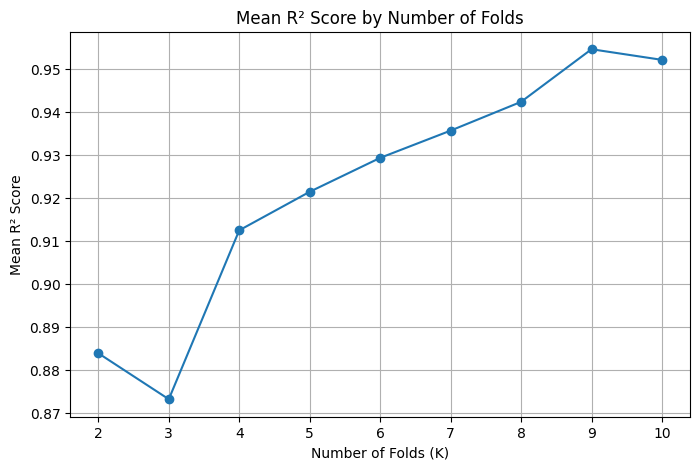

In [8]:
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

folds = range(2, 11)  # try folds from 2 to 10
mean_r2_scores = []

for k in folds:
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    scores = cross_val_score(rfr, X, y, cv=kf, scoring='r2')
    mean_r2_scores.append(np.mean(scores))

# Plot
plt.figure(figsize=(8,5))
plt.plot(folds, mean_r2_scores, marker='o')
plt.title("Mean R² Score by Number of Folds")
plt.xlabel("Number of Folds (K)")
plt.ylabel("Mean R² Score")
plt.grid(True)
#plt.xticks(np.arange(min(x), max(x) + 1, 1))
plt.show()

In [11]:
# Define K-Fold
kf = KFold(n_splits=9, shuffle=True, random_state=42)

# Cross-validation using R² score
cv_scores = cross_val_score(rfr, X, y, cv=kf, scoring='r2')

print("Cross-validation R² scores:", cv_scores)
print("Mean R²:", np.mean(cv_scores))
print("Standard deviation of R²:", np.std(cv_scores))

Cross-validation R² scores: [0.91974857 0.99389943 0.99582179 0.9947472  0.99777486 0.67509459
 0.9980165  0.9968065  0.94242277]
Mean R²: 0.9460369105042982
Standard deviation of R²: 0.09956135496574851


In [12]:
from sklearn.model_selection import cross_val_predict

# Generate out-of-fold predictions for all data
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_all = cross_val_predict(rfr, X, y, cv=kf)

In [13]:
military_power['RFR: MSPI Prediction'] = y_pred_all
military_power['RFR: MSPI Error'] = military_power['Military Strength Power Index'] - military_power['RFR: MSPI Prediction']
military_power['RFR: MSPI Squared Error'] = military_power['RFR: MSPI Error'] ** 2
military_power['RFR: MSPI Absolute Error'] = military_power['RFR: MSPI Error'].abs()
military_power['RFR: MSPI Predicted Ranking'] = military_power['RFR: MSPI Prediction'].rank()
military_power['RFR: MSPI Ranking Error'] = (military_power['Military Strength Power Index Ranking'] - military_power['RFR: MSPI Predicted Ranking'])
military_power

,Country,Military Strength Power Index,Aircraft Strength,Fighter/Interceptor Strength,Attack Aircraft Strength,Transport Aircraft Fleet Strength,Trainer Aircraft Fleet,Helicopter Fleet Strength,Attack Helicopter Fleet Strength,Tank Strength,...,Manpower Available Percentage,Oil Production Surplus or Deficit,Defense Spending Per Capita,Military Strength Power Index Ranking,RFR: MSPI Prediction,RFR: MSPI Error,RFR: MSPI Squared Error,RFR: MSPI Absolute Error,RFR: MSPI Predicted Ranking,RFR: MSPI Ranking Error
0,Afghanistan,1.3444,260,0,25,30,0,187,0,0,...,41.000000,-5500,343.437680,78.0,1.417326,-0.072926,0.005318,0.072926,81.0,-3.0
1,Albania,2.3137,19,0,0,0,0,19,0,0,...,49.699989,-26500,81.773637,115.0,2.309468,0.004232,0.000018,0.004232,114.0,1.0
2,Algeria,0.4659,551,103,22,59,87,257,45,880,...,49.789999,981000,312.068745,28.0,0.428988,0.036912,0.001362,0.036912,27.0,1.0
3,Angola,0.8379,295,72,18,30,47,126,15,379,...,20.570002,1583700,230.597828,56.0,0.824749,0.013151,0.000173,0.013151,52.0,4.0
4,Argentina,0.6521,227,24,7,9,64,100,0,370,...,45.149999,-205600,93.971929,43.0,0.646052,0.006048,0.000037,0.006048,44.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,Venezuela,0.6449,260,38,0,52,82,86,10,390,...,44.999999,1432000,23.509605,41.0,0.627434,0.017466,0.000305,0.017466,41.0,0.0
134,Vietnam,0.3559,293,77,0,38,36,138,25,2615,...,52.600000,-253600,56.677464,22.0,0.318337,0.037563,0.001411,0.037563,20.0,2.0
135,Yemen,1.2412,169,77,0,8,21,61,14,620,...,39.299999,-132740,48.836250,74.0,1.231804,0.009396,0.000088,0.009396,74.0,0.0
136,Zambia,1.6464,108,18,0,11,52,27,0,75,...,37.500002,-21000,2.432339,88.0,1.619320,0.027080,0.000733,0.027080,89.0,-1.0


In [14]:
military_power[['Country', 'RFR: MSPI Error']].sort_values(by='RFR: MSPI Error', ascending=True).head(10)

,Country,RFR: MSPI Error
76,Montenegro,-1.619941
23,Central African Republic,-0.906457
63,Laos,-0.487003
36,El Salvador,-0.406943
74,Moldova,-0.275990
108,Somalia,-0.266253
69,Madagascar,-0.226793
81,Nepal,-0.218468
104,Sierra Leone,-0.107786
80,Namibia,-0.073489


In [15]:
military_power[['Country', 'RFR: MSPI Error']].sort_values(by='RFR: MSPI Error', ascending=False).head(10)

,Country,RFR: MSPI Error
13,Bhutan,6.138635
66,Liberia,1.419668
115,Suriname,0.650106
84,Nicaragua,0.110464
137,Zimbabwe,0.082314
123,Tunisia,0.081705
128,United Arab Emirates,0.077360
25,Chile,0.070676
93,Paraguay,0.065363
46,Guatemala,0.058349


In [16]:
military_power[['Country', 'RFR: MSPI Ranking Error']].sort_values(by='RFR: MSPI Ranking Error', ascending=False).head(10)

,Country,RFR: MSPI Ranking Error
43,Germany,6.0
13,Bhutan,5.0
128,United Arab Emirates,5.0
3,Angola,4.0
88,North Macedonia,4.0
41,Gabon,3.0
48,Hungary,3.0
115,Suriname,3.0
22,Canada,3.0
92,Panama,3.0


In [17]:
military_power[['Country', 'RFR: MSPI Ranking Error']].sort_values(by='RFR: MSPI Ranking Error', ascending=True).head(10)

,Country,RFR: MSPI Ranking Error
76,Montenegro,-14.0
23,Central African Republic,-6.0
74,Moldova,-5.0
96,Poland,-5.0
32,Denmark,-4.0
52,Iraq,-4.0
129,United Kingdom,-4.0
100,Romania,-3.0
112,Spain,-3.0
120,Tajikistan,-3.0


In [18]:
# Calculate correlations with the target column
military_power_corr_df = military_power.drop('Country', axis=1)
correlations = military_power_corr_df.corr()['RFR: MSPI Absolute Error']

In [19]:
# Sort absolute correlations
abs_sorted_correlations = correlations.abs().sort_values(ascending=False)
abs_sorted_correlations

RFR: MSPI Absolute Error                 1.000000
RFR: MSPI Squared Error                  0.955343
RFR: MSPI Error                          0.820062
Military Strength Power Index            0.678118
RFR: MSPI Prediction                     0.379677
Manpower Available Percentage            0.280042
Military Strength Power Index Ranking    0.262396
RFR: MSPI Predicted Ranking              0.260499
Total Border Coverage                    0.096726
Defense Spending Per Capita              0.085638
Frigate Fleet Strength                   0.085138
Navy Fleet Strengths                     0.083347
Towed Artillery Strength                 0.073373
AFV/APC Strength                         0.068184
Tank Strength                            0.065936
Submarine Fleet Strength                 0.061615
Total Square Land Area                   0.056230
Fighter/Interceptor Strength             0.052644
Trainer Aircraft Fleet                   0.051215
Oil Production                           0.050372


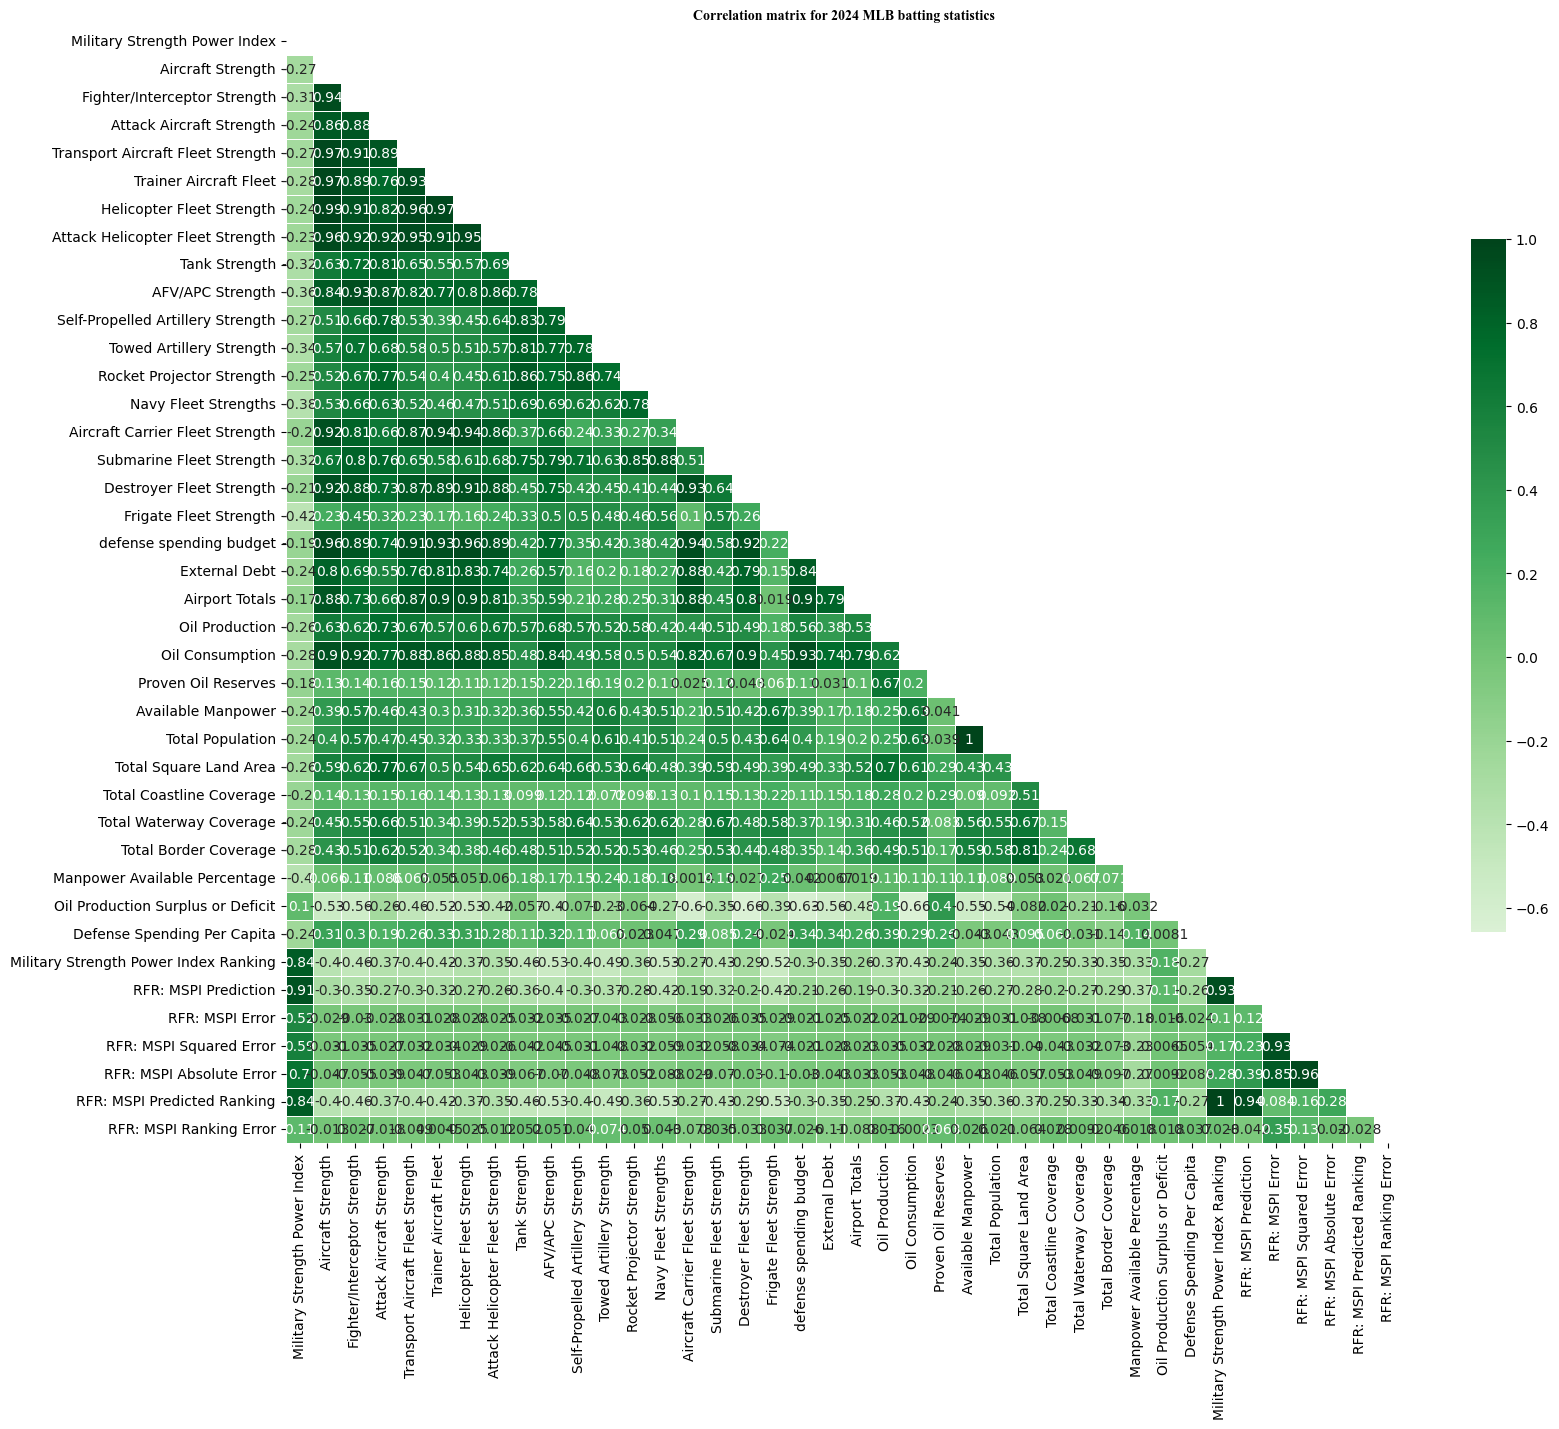

In [35]:
#sns.set(style="whitegrid")

# Generate a mask for the upper triangle
mask = np.zeros_like(military_power_corr_df.corr(numeric_only = True), dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(18, 18))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(military_power_corr_df.corr(numeric_only = True), mask=mask, cmap='Greens', vmax=1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True)

plt.title("Correlation matrix for 2024 MLB batting statistics", font='Times new roman', fontsize=10, fontweight='bold')
#plt.savefig("Correlation matrix for 2024 MLB batting statistics.png")
plt.show()